In [1]:
#Importação de bibliotecas
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Categoriza a idade de um passageiro numa faixa etária específica.
def get_age_category (age):
    if age < 12:
        return 'Children' # Crianças
    elif age < 18:
        return 'Adolescent'# Adolescentes
    elif age < 35:
        return 'Young Adult'# Jovens Adultos
    elif age < 60:
        return 'Adult'# Adultos
    elif age > 60:
        return 'Elder'# Idosos

In [3]:
# Carregar os dados, lê o ficheiro CSV e converte-o para um DataFrame do Pandas
df= pd.read_csv('8887_0.csv')

In [4]:
# Verificação inicial, mostra o resumo do dataset (tipos de dados e número de valores não nulos por coluna)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
# Remoção de dados, elimina a coluna 'Cabin' devido ao elevado número de valores em falta, o que a torna irrelevante
df=df.drop(columns=['Cabin'])

In [6]:
# Verificação da remoção
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [7]:
# Prencher os dados em falta na coluna Age 
# 1. Calcula a mediana de idades exclusivamente para as mulheres
female_median = df[df["Sex"] == "female"]["Age"].median()
# 2. Encontra as mulheres com idade nula e preenche com a mediana calculada
df.loc[(df["Sex"] == "female") & (df["Age"].isnull()), "Age"] = female_median


In [8]:
# Prencher os dados em falta na coluna Age 
# 1. Calcula a mediana de idades exclusivamente para os homens
male_median = df[df["Sex"] == "male"]["Age"].median()
# 2. Encontra os homens com idade nula e preenche com a mediana calculada
df.loc[(df["Sex"] == "male") & (df["Age"].isnull()), "Age"] = male_median


In [9]:
# Verificação da alterção da coluna Age
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [10]:
#Prenchimento dos dados na coluna Embarked
# Encontra o valor mais frequente e da-mos uma variavel
valor_mais_comum = df['Embarked'].mode()[0]
# Preenche os poucos valores nulos de 'Embarked' com o valor mais comum
df['Embarked'].fillna(valor_mais_comum, inplace=True)

C:\Users\joaov\AppData\Local\Temp\ipykernel_8636\2776092795.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(valor_mais_comum, inplace=True)


In [11]:
#Verificação de que os dois valores foram alterados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


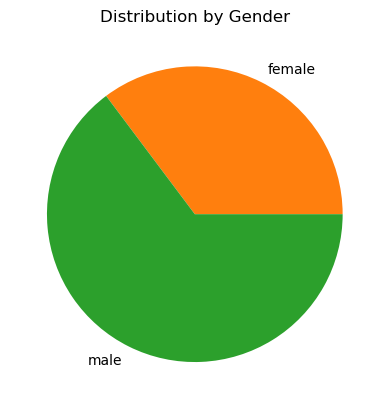

In [12]:
# Gráfico de Distribuição por Género
# Agrupa os dados por sexo, conta os passageiros e cria um gráfico pie chart
df.groupby('Sex')['PassengerId'].count().plot.pie(
    title='Distribution by Gender',
    colors= ['C1', 'C2'],
    ylabel= '' # Oculta a etiqueta do eixo Y para melhorar a estética
    )
plt.savefig('Distribution by Gender') # Guarda o gráfico como imagem
plt.show()


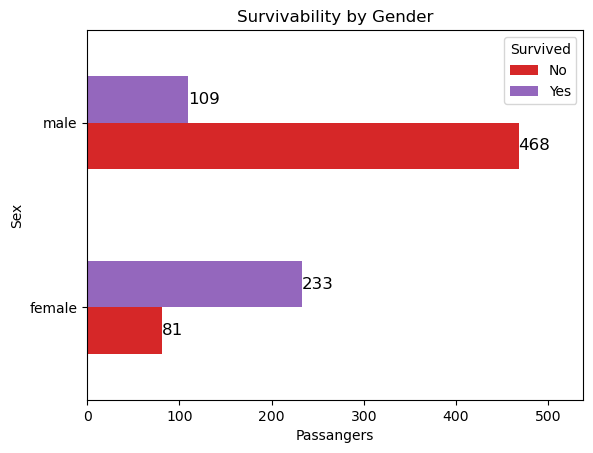

In [25]:
# Gráfico de Sobrevivência por Género
# Cria uma pivot table que cruza Sexo e Sobrevivência
tabela_pivot = df.pivot_table(index='Sex', 
                              columns='Survived', 
                              values='PassengerId', 
                              aggfunc='count')
# Desenha o gráfico de barras horizontais
genderd=tabela_pivot.plot.barh(
    title='Survivability by Gender',
    color=['C3','C4'],
    stacked = False
    )
plt.legend(title='Survived', labels=['No', 'Yes']) #Alteração dos valores 0 e 1 para aparecer respetivamente No e Yes
plt.bar_label(genderd.containers[0],size=12) # Adiciona as contagens no lado de cada barra
plt.bar_label(genderd.containers[1],size=12) # Adiciona as contagens no lado de cada barra
plt.margins(x=0.15)
plt.xlabel('Passangers')
plt.ylabel('Sex')
plt.savefig('Survivability by Gender')
plt.show()

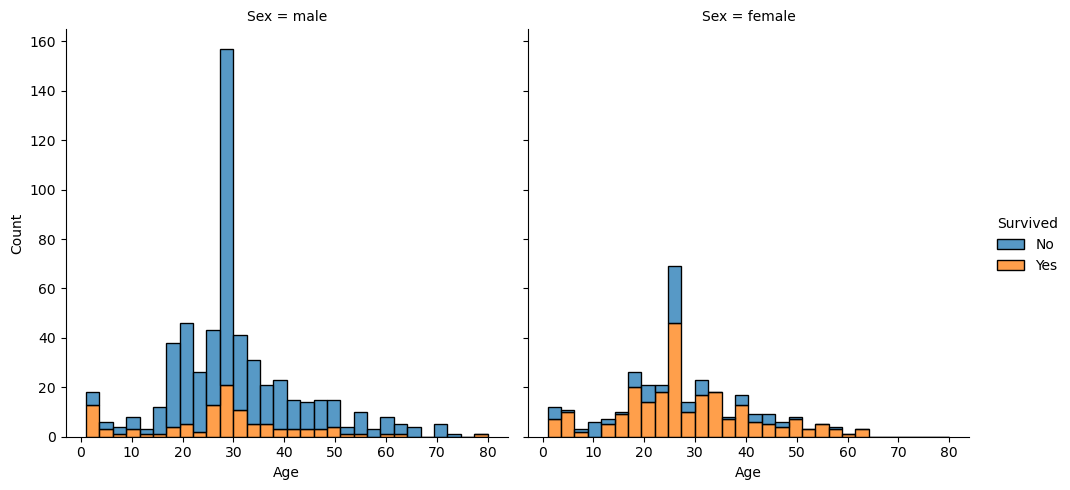

In [36]:
# Gráficos de Idade vs Sobrevivência (Separado por Género)
# Usa o seaborn (sns) para criar um gráfico de distribuição 
sns.displot(
    data=df,
    x='Age', 
    col='Sex', # Divide em dois gráficos
    hue=df['Survived'].map({0: 'No', 1: 'Yes'}), # Pinta as barras consoante a sobrevivência
    multiple='stack', # Empilha os valores em vez de os sobrepor
    palette='tab10'
)
plt.savefig('Comparation beetween male and female')
plt.show()

In [15]:
# Seleção de variáveis numéricas
# Isola as colunas numéricas que farão parte do cálculo de correlação
d=df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']]

In [16]:
# Cálculo da matriz de correlação
corr_mtx=d.corr()

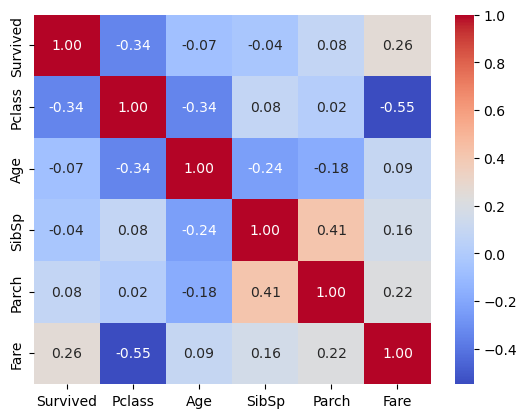

In [17]:
# Célula 17: Criação do Heatmap (Mapa de Calor)
sns.heatmap(corr_mtx, annot=True, cmap='coolwarm', fmt=".2f") # annot=True mostra os valores numéricos, fmt=".2f" formata para 2 casas decimais
plt.savefig('Heatmap')
plt.show()


In [41]:
# Cria uma pivot table que cruza Pais e Sobrevivência
tabela_pivot1 = df.pivot_table(index='Parch',
                              columns='Survived', 
                              values='PassengerId', 
                              aggfunc='count')
tabela_pivot1 = tabela_pivot1.drop(index=6)

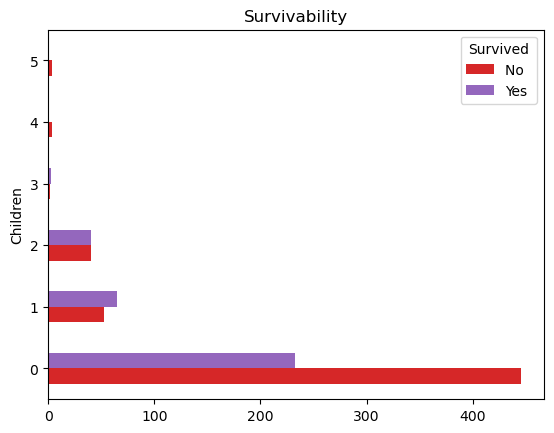

In [42]:
# Gráfico de Sobrevivência por Número de Pais (Parch)
childrend=tabela_pivot1.plot.barh(
    title='Survivability',
    color=['C3','C4'],
    stacked = False
    )
plt.legend(title='Survived', labels=['No ', 'Yes ']) #Alteração dos valores 0 e 1 para aparecer respetivamente No e Yes
plt.ylabel('Children')
plt.xlabel('')
plt.savefig('Survivability')
plt.show()


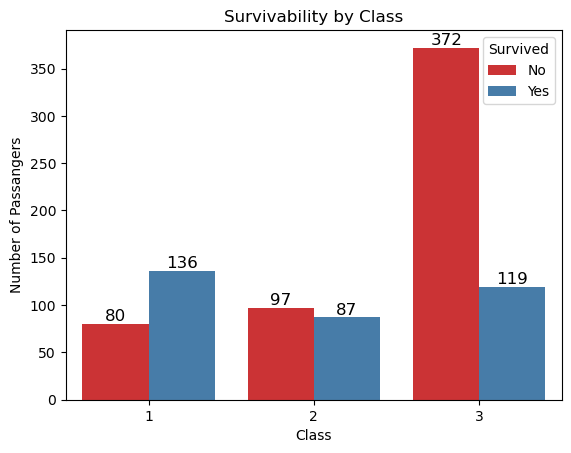

In [44]:
# Célula 20: Gráfico de Sobrevivência por Classe (Pclass)
# Cria um plot cruzando a Classe com a Sobrevivência
splot=sns.countplot(data=df, x='Pclass', hue='Survived', palette='Set1')
plt.title("Survivability by Class")
plt.bar_label(splot.containers[0],size=12) #Adiciona as contagens reais no topo de cada barra
plt.bar_label(splot.containers[1],size=12) #Adiciona as contagens reais no topo de cada barra
plt.xlabel("Class")
plt.ylabel("Number of Passangers")
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.savefig('Survivability by Class')
plt.show()


In [21]:
# Mapeia a função 'get_age_category' a todos os valores da coluna 'Age' e cria nova coluna
df['Age_Category'] = df['Age'].apply(get_age_category)

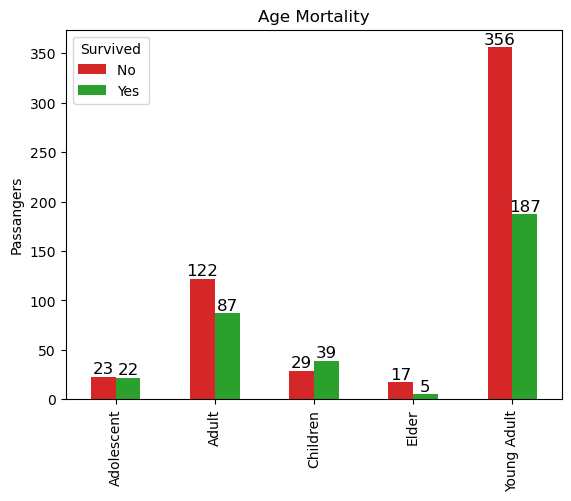

In [28]:
# Mortalidade por Faixa Etária
# Cria a tabela dinâmica baseada nas novas faixas etárias
tabela_pivot2 = df.pivot_table(index='Age_Category',
                              columns='Survived', 
                              values='PassengerId', 
                              aggfunc='count')
# Gera o gráfico de barras verticais
splot=tabela_pivot2.plot.bar(
    title='Age Mortality',
    color=['C3','C2']
)
plt.xlabel('')
plt.bar_label(splot.containers[0],size=12)
plt.bar_label(splot.containers[1],size=12)
plt.ylabel('Passangers')
plt.legend(title='Survived', labels=['No ', 'Yes '])
plt.savefig('Age Mortality')
plt.show()